# cGAN

In [2]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.data import AUTOTUNE
from PIL import Image

In [3]:
# Define paths
json_path = "D:\\sem3\\Image-Data\\photos.json"
photos_folder = "D:\\sem3\\Image-Data\\photos\\"
subset_folder = "D:\\sem3\\Image-Data\\subset-photos\\"

# Load JSON metadata
photos_data = []
with open(json_path, "r", encoding="utf-8") as f:
    for line in f:
        photos_data.append(json.loads(line))

# Convert to DataFrame
photos_df = pd.DataFrame(photos_data)

# Sample 20,000 images
subset_df = photos_df.sample(n=20000, random_state=42)

# Define label categories
LABELS = ["food", "drink", "inside", "outside"]

# Function to preprocess images
IMG_SIZE = 64  # Resize to 64x64 for faster training
BATCH_SIZE = 64

In [4]:
def load_and_preprocess_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))  
    img = img_to_array(img) / 127.5 - 1  # Normalize to [-1, 1]
    return img

# Load images and labels
image_paths, labels = [], []
skipped_images = []
for _, row in subset_df.iterrows():
    img_path = os.path.join(subset_folder, row["photo_id"] + ".jpg")
    if os.path.exists(img_path):  
        try:
            # Try loading image to check if it's valid
            _ = load_and_preprocess_image(img_path)
            image_paths.append(img_path)
            # Handle label parsing
            raw_label = row["label"].strip("[]").replace("'", "")
            label_list = [lbl.strip() for lbl in raw_label.split(",")]
            # One-hot encode labels
            label_vector = [1 if lbl in label_list else 0 for lbl in LABELS]
            labels.append(label_vector)
        except (Image.UnidentifiedImageError, OSError):
            skipped_images.append(img_path)

# Convert to NumPy arrays
images_np = np.array([load_and_preprocess_image(p) for p in image_paths])
labels_np = np.array(labels)

# Create TensorFlow dataset
dataset = tf.data.Dataset.from_tensor_slices((images_np, labels_np))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [5]:
import tensorflow as tf

tfrecord_path = "yelp_dataset_for_cGAN.tfrecord"

def serialize_example(image, label):
    feature = {
        "image": tf.train.Feature(bytes_list=tf.train.BytesList(value=[tf.io.encode_jpeg(tf.cast((image + 1) * 127.5, tf.uint8)).numpy()])),
        "label": tf.train.Feature(int64_list=tf.train.Int64List(value=label))
    }
    example_proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return example_proto.SerializeToString()

with tf.io.TFRecordWriter(tfrecord_path) as writer:
    for i in range(len(images_np)):
        example = serialize_example(images_np[i], labels_np[i])
        writer.write(example)

print(f"Dataset saved to {tfrecord_path}")

In [6]:
# def parse_example(example_proto):
#     feature_description = {
#         "image": tf.io.FixedLenFeature([], tf.string),
#         "label": tf.io.FixedLenFeature([4], tf.int64),
#     }
#     example = tf.io.parse_single_example(example_proto, feature_description)
    
#     image = tf.io.decode_jpeg(example["image"])  # Decode first
#     image = tf.image.convert_image_dtype(image, tf.float32)  # Convert to float32
#     image = (image - 0.5) * 2  # Normalize to [-1,1]
#     image = tf.image.resize(image, [64, 64])  # Ensure correct size
    
#     return image, example["label"]

# dataset = tf.data.TFRecordDataset("yelp_dataset_for_cGAN.tfrecord")
# dataset = dataset.map(parse_example).shuffle(10000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
print(f"Skipped {len(skipped_images)} corrupted images.")
# Show some images
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow((images_np[i] + 1) / 2)  # Convert back to [0,1]
    plt.axis("off")
plt.show()

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

NOISE_DIM = 100  # Size of the random noise vector

def build_generator():
    noise_input = layers.Input(shape=(NOISE_DIM,))
    label_input = layers.Input(shape=(4,))  # One-hot encoded labels

    # Concatenate noise and label
    x = layers.Concatenate()([noise_input, label_input])

    # Fully connected layers
    x = layers.Dense(8 * 8 * 256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    x = layers.Reshape((8, 8, 256))(x)

    # Convolutional layers (upsampling)
    x = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    x = layers.Conv2DTranspose(3, (4, 4), strides=(2, 2), padding="same", activation="tanh")(x)

    return tf.keras.Model([noise_input, label_input], x, name="Generator")

generator = build_generator()
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 104)               │               0 │ input_layer[0][0],         │
│                               │                           │                 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 16384)             │       1,703,936 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 16384)             │          65,536 │ dense[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 16384)             │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 8, 8, 256)         │               0 │ leaky_re_lu[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 16, 16, 128)       │         524,288 │ reshape[0][0]              │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 16, 16, 128)       │             512 │ conv2d_transpose[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 16, 16, 128)       │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_1            │ (None, 32, 32, 64)        │         131,072 │ leaky_re_lu_1[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 32, 32, 64)        │             256 │ conv2d_transpose_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 32, 32, 64)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_2            │ (None, 64, 64, 3)         │           3,075 │ leaky_re_lu_2[0][0]        │
│ (Conv2DTranspose)             │                           │               

 Total params: 2,428,675 (9.26 MB)

 Trainable params: 2,395,523 (9.14 MB)

 Non-trainable params: 33,152 (129.50 KB)

In [9]:
def build_discriminator():
    img_input = layers.Input(shape=(64, 64, 3))
    label_input = layers.Input(shape=(4,))

    # Expand label to match image size and concatenate
    label_expanded = layers.Dense(64 * 64 * 1)(label_input)
    label_expanded = layers.Reshape((64, 64, 1))(label_expanded)
    x = layers.Concatenate()([img_input, label_expanded])

    # Convolutional layers
    x = layers.Conv2D(64, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(256, (4, 4), strides=(2, 2), padding="same")(x)
    x = layers.LeakyReLU()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1, activation="sigmoid")(x)

    return tf.keras.Model([img_input, label_input], x, name="Discriminator")

discriminator = build_discriminator()
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4096)              │          20,480 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 64, 64, 3)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape_1 (Reshape)           │ (None, 64, 64, 1)         │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 64, 64, 4)         │               0 │ input_layer_2[0][0],       │
│                               │                           │                 │ reshape_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 32, 32, 64)        │           4,160 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 32, 32, 64)        │               0 │ conv2d[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 32, 32, 64)        │               0 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 16, 16, 128)       │         131,200 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_4 (LeakyReLU)     │ (None, 16, 16, 128)       │               0 │ conv2d_1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 16, 16, 128)       │               0 │ leaky_re_lu_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 8, 8, 256)         │         524,544 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_5 (LeakyReLU)     │ (None, 8, 8, 256)         │               0 │ conv2d_2[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 8, 8, 256)         │               0 │ leaky_re_lu_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 16384)             │               0 │ dropout_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 1)                 │          16,385 │ flatten[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 696,769 (2.66 MB)

 Trainable params: 696,769 (2.66 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

In [11]:
@tf.function
def train_step(images, labels):
    noise = tf.random.normal([images.shape[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator([noise, labels], training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [12]:
import time
from tqdm import tqdm  # Progress bar

# Ensure TensorFlow is using CUDA
physical_devices = tf.config.experimental.list_physical_devices("GPU")
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"Using GPU: {physical_devices[0]}")
else:
    print("No GPU found. Using CPU.")

# Updated training loop
EPOCHS = 50  # Set to higher value since we're optimizing speed

for epoch in range(EPOCHS):
    start_time = time.time()
    epoch_g_loss = []
    epoch_d_loss = []

    progress_bar = tqdm(dataset, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)

    for image_batch, label_batch in progress_bar:
        g_loss, d_loss = train_step(image_batch, label_batch)
        epoch_g_loss.append(g_loss.numpy())
        epoch_d_loss.append(d_loss.numpy())

        # Update progress bar with loss
        progress_bar.set_postfix(G_Loss=f"{g_loss.numpy():.4f}", D_Loss=f"{d_loss.numpy():.4f}")

    end_time = time.time()
    avg_g_loss = np.mean(epoch_g_loss)
    avg_d_loss = np.mean(epoch_d_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Time: {end_time - start_time:.2f}s | "
          f"Generator Loss: {avg_g_loss:.4f} | Discriminator Loss: {avg_d_loss:.4f}")

No GPU found. Using CPU.


Epoch 1/50: 0it [00:00, ?it/s]C:\Users\chetn\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:780: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
Epoch 1/50: 313it [01:35,  3.28it/s, D_Loss=1.1363, G_Loss=1.6236]


Epoch 1/50 | Time: 95.51s | Generator Loss: 2.7143 | Discriminator Loss: 0.6049


Epoch 2/50: 313it [01:29,  3.48it/s, D_Loss=0.7654, G_Loss=1.6027]


Epoch 2/50 | Time: 89.82s | Generator Loss: 1.4779 | Discriminator Loss: 0.9268


...

Epoch 48/50 | Time: 96.28s | Generator Loss: 4.4847 | Discriminator Loss: 0.2594


Epoch 49/50: 313it [01:35,  3.26it/s, D_Loss=0.3019, G_Loss=3.7603] 


Epoch 49/50 | Time: 95.89s | Generator Loss: 4.6824 | Discriminator Loss: 0.2192


Epoch 50/50: 313it [01:36,  3.25it/s, D_Loss=0.3086, G_Loss=4.8163]

Epoch 50/50 | Time: 96.37s | Generator Loss: 4.4828 | Discriminator Loss: 0.2440


Images saved in generated_samples


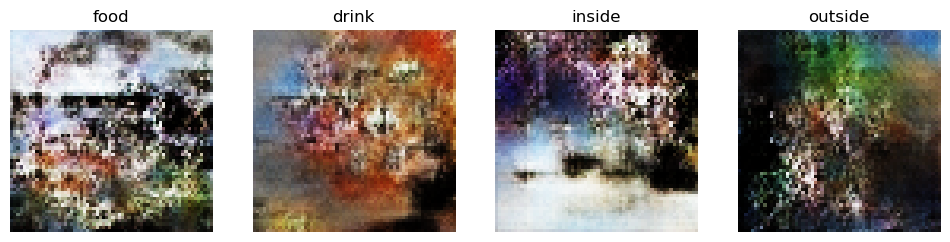

In [13]:
import os

save_dir = "generated_samples"
os.makedirs(save_dir, exist_ok=True)

def generate_save_plot_images():
    noise = tf.random.normal([4, NOISE_DIM])
    sample_labels = tf.eye(4)  # One-hot labels for food, drink, inside, outside
    generated_images = generator([noise, sample_labels], training=False)

    fig, axs = plt.subplots(1, 4, figsize=(12, 3))
    for i, img in enumerate(generated_images):
        img = (img + 1) / 2  # Convert to [0,1] range
        plt.imsave(f"{save_dir}/{LABELS[i]}.png", img.numpy())  # Save images
        axs[i].imshow(img)
        axs[i].axis("off")
        axs[i].set_title(LABELS[i])
    
    print(f"Images saved in {save_dir}")
    plt.show()
    

generate_save_plot_images()

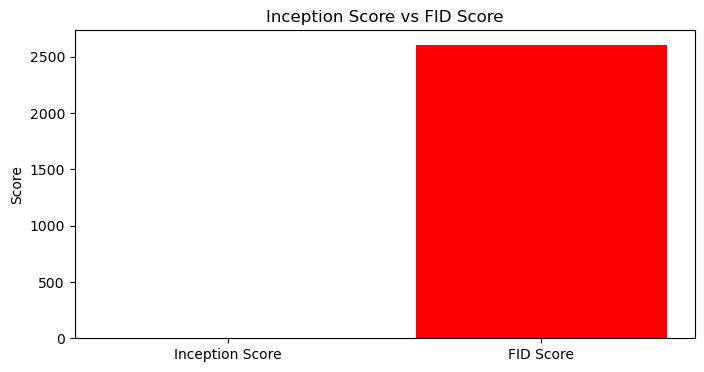

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm

def calculate_is_fid(real_images, fake_images):
    # Convert tensors to NumPy arrays
    real_images = real_images.numpy()
    fake_images = fake_images.numpy()

    # Compute statistics for IS
    p_yx = tf.nn.softmax(fake_images)  # Using fake images for IS
    p_y = tf.reduce_mean(p_yx, axis=0)
    kl_div = tf.reduce_sum(p_yx * tf.math.log(p_yx / p_y), axis=1)
    inception_score = tf.exp(tf.reduce_mean(kl_div))

    # **Reduce Dimensionality: Compute mean across spatial dimensions**
    mu_real = np.mean(real_images, axis=(0, 1, 2))  # Mean per channel
    mu_fake = np.mean(fake_images, axis=(0, 1, 2))  # Mean per channel

    # Compute covariance only for channels (3x3 matrix instead of huge 192000x192000)
    real_images_flat = real_images.reshape(real_images.shape[0], -1)  # (num_samples, features)
    fake_images_flat = fake_images.reshape(fake_images.shape[0], -1)  # (num_samples, features)
    
    sigma_real = np.cov(real_images_flat, rowvar=False)
    sigma_fake = np.cov(fake_images_flat, rowvar=False)

    # Compute FID
    diff = mu_real - mu_fake
    sqrt_cov = sqrtm(sigma_real @ sigma_fake)

    # Ensure sqrt_cov is real-valued
    if np.iscomplexobj(sqrt_cov):
        sqrt_cov = sqrt_cov.real

    fid_score = np.linalg.norm(diff) + np.trace(sigma_real + sigma_fake - 2 * sqrt_cov)

    return inception_score.numpy(), fid_score

# Generate fake images
num_images = 1000
NOISE_DIM = 100  
noise = tf.random.normal([num_images, NOISE_DIM])
labels = tf.one_hot(np.random.choice(4, num_images), depth=4)
generated_images = generator([noise, labels], training=False)

# Select real images
real_images, _ = next(iter(dataset.take(1)))

# Ensure real and fake images have the same shape
real_images = real_images[:num_images]

# Compute scores
is_score, fid_score = calculate_is_fid(real_images, generated_images)

# **Plot IS and FID scores**
plt.figure(figsize=(8, 4))
plt.bar(["Inception Score", "FID Score"], [is_score, fid_score], color=['blue', 'red'])
plt.ylabel("Score")
plt.title("Inception Score vs FID Score")
plt.show()

In [36]:
print("Inception Score", is_score)
print("FID Score", fid_score)

Inception Score 1.2030339
FID Score 2605.8033126957644


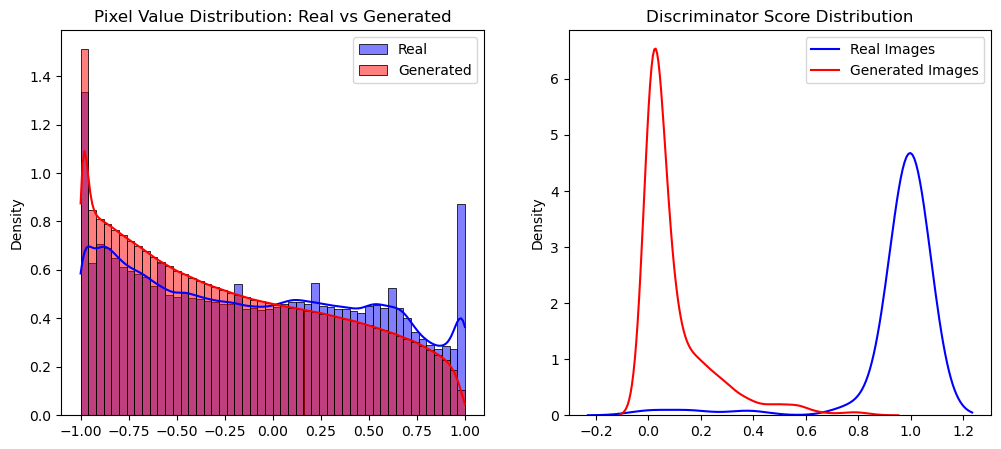

In [40]:
import seaborn as sns

def plot_distributions(real_images, fake_images, real_labels, fake_labels, discriminator):
    # Flatten images only for visualization, keep original tensors for discriminator input
    real_images_flat = tf.reshape(real_images, [-1])  # Flatten pixel values for visualization
    fake_images_flat = tf.reshape(fake_images, [-1])

    # Plot pixel distributions
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(real_images_flat.numpy(), bins=50, color='blue', label='Real', kde=True, stat="density")
    sns.histplot(fake_images_flat.numpy(), bins=50, color='red', label='Generated', kde=True, stat="density")
    plt.title("Pixel Value Distribution: Real vs Generated")
    plt.legend()

    # Get discriminator outputs by passing both images and labels (keep as tensors)
    real_scores = discriminator([real_images, real_labels])
    fake_scores = discriminator([fake_images, fake_labels])

    # Convert discriminator outputs to numpy for plotting
    real_scores = real_scores.numpy()
    fake_scores = fake_scores.numpy()

    # Plot Discriminator Scores
    plt.subplot(1, 2, 2)
    sns.kdeplot(real_scores.flatten(), color='blue', label="Real Images")
    sns.kdeplot(fake_scores.flatten(), color='red', label="Generated Images")
    plt.title("Discriminator Score Distribution")
    plt.legend()

    plt.show()

# Select real images and labels
real_images, real_labels = next(iter(dataset.take(1)))
real_images = real_images[:1000]  # Use consistent number of real images
real_labels = real_labels[:1000]  # Corresponding labels

# Reuse generated images and labels from the previous IS/FID generation step
fake_images = generated_images  # Already generated fake images
fake_labels = labels  # Labels used during generation

# Plot distributions with real images, fake images, and labels
plot_distributions(real_images, fake_images, real_labels, fake_labels, discriminator)

In [ ]:
# Show 5 generated images with labels
num_images_to_show = 5

# Generate a plot
plt.figure(figsize=(10, 10))

for i in range(num_images_to_show):
    plt.subplot(1, num_images_to_show, i + 1)
    plt.imshow((generated_images[i] * 0.5) + 0.5)  # Rescale images to [0, 1] for visualization
    plt.title(f"Label: {labels[i].numpy()}")
    plt.axis('off')

plt.show()

## Results and Observations
- **Inception Score (IS): 1.2030**
- **FID Score: 2605.80**
- *The generator ran for 50 epochs and has begun learning, with the tail of the generated image distribution gradually shifting toward the real distribution.*
- *The generator seem to understand the low level features, and with more epochs while utilizing GPU will allow the generator to perform betterand faster.*